# Distgen laser image for `sc_inj`

Taken for 50 pC spot

In [1]:
import numpy as np
import json
import os

# Nicer plotting
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
from distgen import Generator

D = Generator('distgen.yaml')
D.run()

P0 = D.particles
D

<disgten.Generator with input: 
n_particle: 100000
random_type: hammersley
start:
  MTE:
    units: meV
    value: 330
  type: cathode
t_dist:
  avg_t:
    units: ps
    value: 0
  n_sigma_cutoff: 3
  sigma_t:
    units: ps
    value: 8.5
  type: gaussian
total_charge:
  units: pC
  value: 50
xy_dist:
  file: /Users/chrisonian/Code/GitHub/lcls-lattice/distgen/models/sc_inj/vcc_image/laser_image.txt
  type: file2d

>

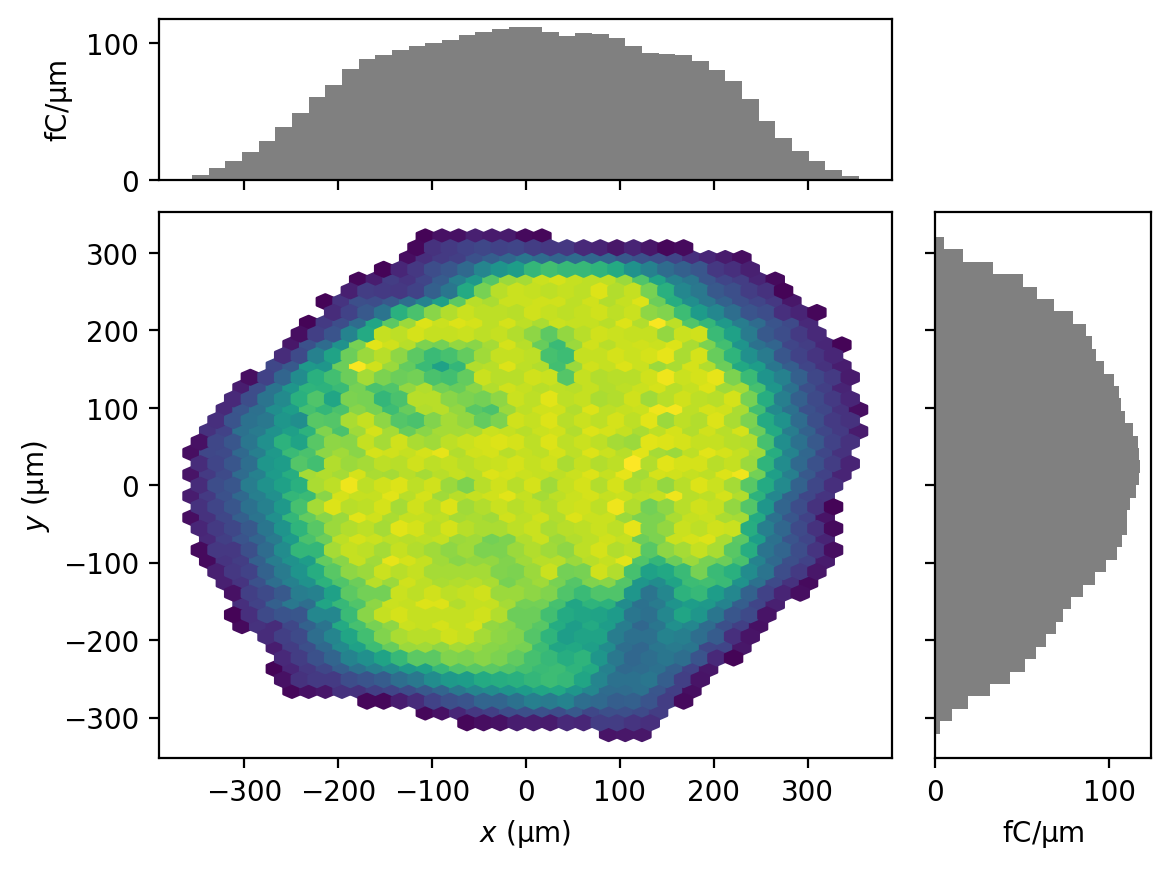

In [3]:
P0.plot('x', 'y', bins=40)

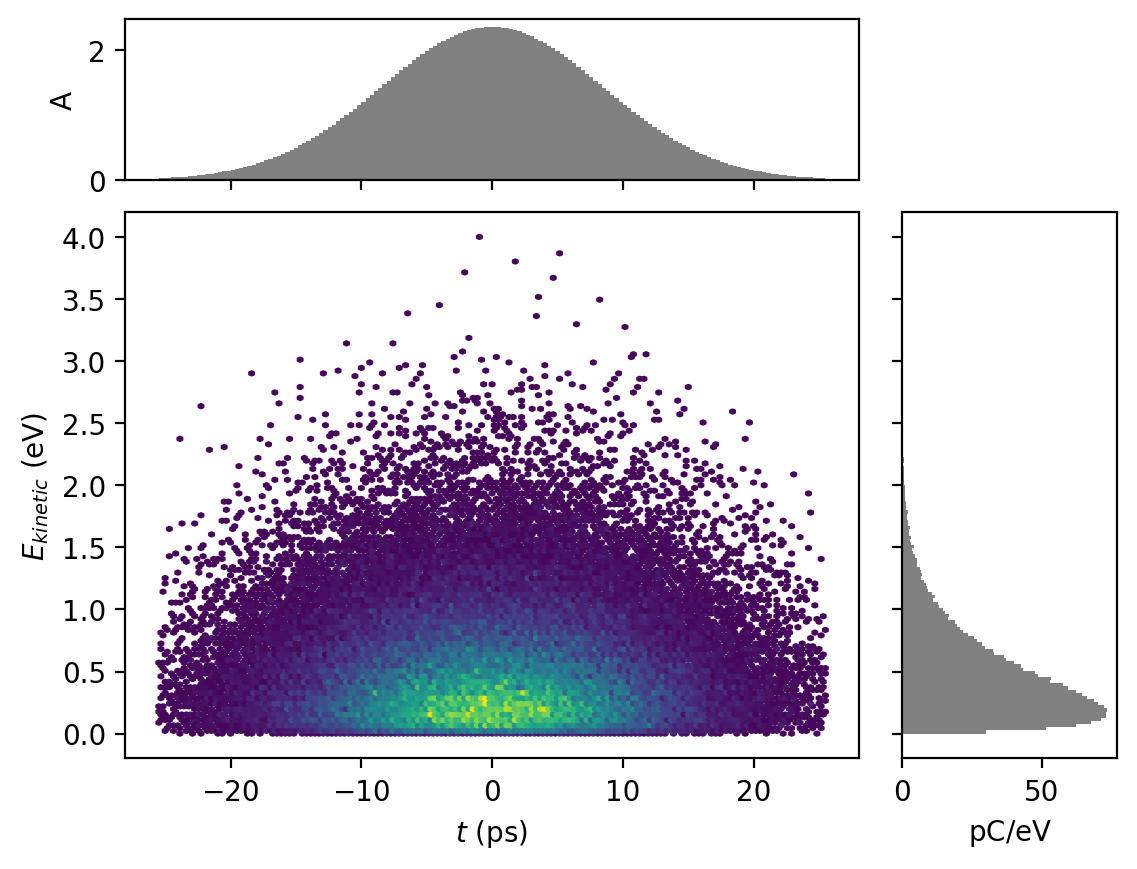

In [4]:
P0.plot('t', 'kinetic_energy')

# Compare with ideal

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


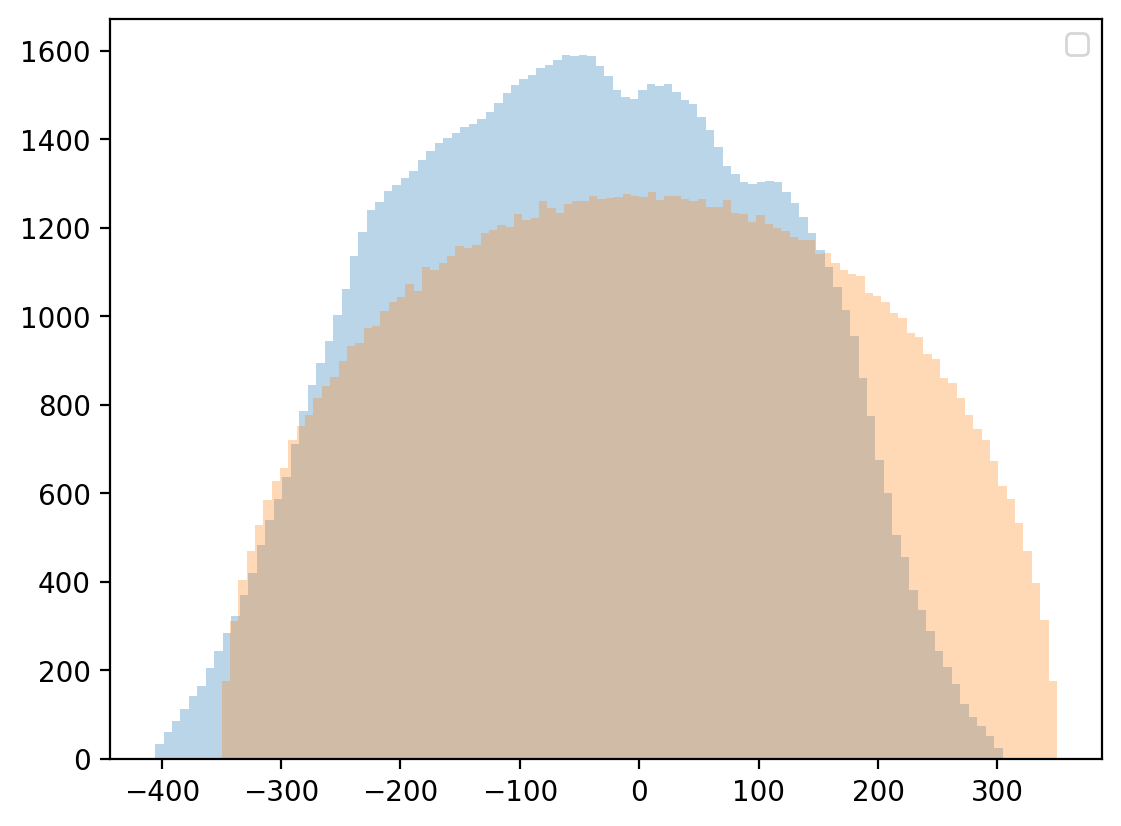

In [5]:
D2 = Generator('../v0/distgen.yaml')
D2['r_dist:max_r:value'] = 0.35
P2 = D2.run()

fig, ax = plt.subplots()
ax.hist(P0.x*1e6 - 50, bins=100, alpha= 0.3);
ax.hist(P2.x*1e6, bins=100, alpha= 0.3);
plt.legend()